# Étape 2 — Réduction de variance

L'erreur standard du Monte Carlo vaut $\sigma_Y / \sqrt{N}$. On ne peut pas améliorer le $\sqrt{N}$, mais on peut construire des estimateurs de **même espérance** et de **variance plus faible**.

Trois méthodes, comparées au Monte Carlo standard :
1. **Variables antithétiques** : on utilise $Z$ et $-Z$.
2. **Variable de contrôle** : on corrige avec $X = e^{-rT} S_T$, dont l'espérance $S_0$ est connue.
3. **Quasi-Monte Carlo randomisé** : suite de Sobol avec décalage aléatoire.

Toutes les méthodes renvoient le même format `(prix, erreur standard, IC)` pour être directement comparables.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

## 1. Briques de base (reprises de l'étape 1, réorganisées)

In [2]:
# Code : mcpricing/payoffs.py, mcpricing/closed_form.py,
# mcpricing/simulation.py (terminal_prices : les Z sont passés en entrée)
# et mcpricing/engine.py (summarize : statistiques communes, quantile de Student)
from mcpricing.payoffs import call_payoff, put_payoff
from mcpricing.closed_form import bs_call_price, bs_put_price

## 2. Monte Carlo standard (référence)

$\hat C_N = \frac1N \sum_i Y_i$ avec $Y_i = e^{-rT} h(S_T^{(i)})$.

In [3]:
# Code : mcpricing/engine.py. Le Monte Carlo standard est l'estimateur mc_price de l'étape 1.
from mcpricing.engine import mc_price as mc_standard

## 3. Variables antithétiques

Pour chaque $Z_i$, on calcule $Y_i = h(Z_i)$ et $Y_i' = h(-Z_i)$, puis la moyenne de la paire $\bar Y_i = (Y_i + Y_i')/2$.

$$\mathrm{Var}(\bar Y_i) = \frac{\sigma_Y^2}{2}(1 + \rho), \qquad \rho = \mathrm{Corr}(Y, Y').$$

Gain si $\rho < 0$, garanti pour un payoff monotone en $Z$ (call, put).

⚠️ L'erreur standard se calcule sur les $n$ **moyennes de paires** (indépendantes), pas sur les $2n$ payoffs (corrélés deux à deux).

Coût : $n$ paires = $2n$ évaluations de payoff.

In [4]:
# Code : mcpricing/variance_reduction.py
from mcpricing.variance_reduction import mc_antithetic

### 3 bis. Pourquoi $\rho \le 0$ pour un payoff monotone

**Le cadre.** On note $g(z) = e^{-rT}\,h\Big(S_0\, e^{(r-\sigma^2/2)T + \sigma\sqrt T\, z}\Big)$ le payoff actualisé vu comme fonction de la gaussienne, $Y = g(Z)$ et $Y' = g(-Z)$. On a montré que, **à budget égal** de $2n$ évaluations de payoff :

$$\operatorname{Var}(\tilde Y_i) = \frac{\sigma_Y^2}{2}(1+\rho), \qquad \frac{\operatorname{Var}\big(\hat C^{\text{std}}_{2n}\big)}{\operatorname{Var}\big(\hat C^{\text{anti}}_n\big)} = \frac{1}{1+\rho}, \qquad \rho = \operatorname{Corr}\big(g(Z), g(-Z)\big)$$

La méthode est utile si et seulement si $\rho < 0$ ; elle **double** la variance dans le pire cas $\rho = 1$. Le résultat suivant garantit qu'on ne perd jamais pour un call ou un put.

**Proposition.** Si $g$ est monotone, alors $\operatorname{Cov}\big(g(Z), g(-Z)\big) \le 0$, donc $\rho \le 0$.

**Preuve.** Supposons $g$ croissante (le cas décroissant est identique). Posons $f(z) = g(z)$, croissante, et $k(z) = g(-z)$, décroissante. Soit $Z'$ une copie indépendante de $Z$. Pour tous réels $z, z'$, les quantités $f(z) - f(z')$ et $k(z) - k(z')$ sont de signes opposés, donc

$$\big(f(Z) - f(Z')\big)\big(k(Z) - k(Z')\big) \le 0.$$

En prenant l'espérance et en développant, comme $Z$ et $Z'$ sont i.i.d. :

$$\mathbb E\big[f(Z)k(Z)\big] - \mathbb E\big[f(Z)\big]\mathbb E\big[k(Z')\big] - \mathbb E\big[f(Z')\big]\mathbb E\big[k(Z)\big] + \mathbb E\big[f(Z')k(Z')\big] = 2\operatorname{Cov}\big(f(Z), k(Z)\big) \le 0,$$

et $\operatorname{Cov}\big(f(Z), k(Z)\big) = \operatorname{Cov}\big(g(Z), g(-Z)\big)$. $\blacksquare$

Le call ($g$ croissante) et le put ($g$ décroissante) ne font donc **jamais** pire que le Monte Carlo standard. Pour un payoff non monotone, il n'y a aucune garantie.

**Ce que la méthode supprime.** Toute fonction se décompose en partie paire et partie impaire :

$$g(z) = \underbrace{\frac{g(z) + g(-z)}{2}}_{g_{\text{paire}}(z)} + \underbrace{\frac{g(z) - g(-z)}{2}}_{g_{\text{impaire}}(z)}, \qquad \tilde Y = g_{\text{paire}}(Z), \qquad \operatorname{Var}(\tilde Y) = \operatorname{Var}\big(g_{\text{paire}}(Z)\big).$$

La méthode élimine **exactement la partie impaire** du payoff :
- payoff presque linéaire en $Z$ (call très dans la monnaie) : gros gain ;
- payoff presque nul sauf pour les grands $Z$ (call très hors de la monnaie) : gain quasi nul ;
- payoff **pair** en $Z$ : rien à supprimer, $\rho = 1$, variance **doublée**.

**Vérification numérique.** On estime $\rho$ et le facteur $\frac{1}{1+\rho}$ pour un call, un put, un payoff non monotone (spread papillon) et un payoff pair en $Z$, $h(S_T) = \big(\ln(S_T/S_0) - (r - \tfrac{\sigma^2}{2})T\big)^2 = \sigma^2 T\, Z^2$.

In [5]:
# Code : mcpricing/variance_reduction.py
from mcpricing.variance_reduction import antithetic_check

S0_, T_, r_, sigma_ = 100.0, 1.0, 0.03, 0.2
drift_ = (r_ - 0.5 * sigma_**2) * T_
cases = {
    "Call K=100 (croissant)":        lambda ST: np.maximum(ST - 100.0, 0.0),
    "Call K=70 (croissant)":         lambda ST: np.maximum(ST - 70.0, 0.0),
    "Call K=130 (croissant)":        lambda ST: np.maximum(ST - 130.0, 0.0),
    "Put K=100 (décroissant)":       lambda ST: np.maximum(100.0 - ST, 0.0),
    "Papillon 90/100/110 (non monotone)":
        lambda ST: np.maximum(ST - 90, 0) - 2 * np.maximum(ST - 100, 0) + np.maximum(ST - 110, 0),
    "Pair en Z : (ln(S_T/S0) - drift)²": lambda ST: (np.log(ST / S0_) - drift_)**2,
}

print(f"{'Payoff':<38} {'ρ':>8} {'Facteur 1/(1+ρ)':>17}")
for name, h in cases.items():
    rho, factor = antithetic_check(h)
    print(f"{name:<38} {rho:>+8.3f} {factor:>17.2f}")

Payoff                                        ρ   Facteur 1/(1+ρ)
Call K=100 (croissant)                   -0.445              1.80
Call K=70 (croissant)                    -0.937             15.89
Call K=130 (croissant)                   -0.059              1.06


Put K=100 (décroissant)                  -0.477              1.91
Papillon 90/100/110 (non monotone)       +0.901              0.53
Pair en Z : (ln(S_T/S0) - drift)²        +1.000              0.50


Les payoffs monotones ont bien $\rho \le 0$ (gain garanti, très fort dans la monnaie, quasi nul hors de la monnaie). Le papillon, non monotone, n'a aucune garantie. Le payoff pair en $Z$ a $\rho = 1$ : les variables antithétiques **doublent** la variance.

## 4. Variable de contrôle

On utilise $X = e^{-rT} S_T$, dont l'espérance est connue : $\mathbb E_{\mathbb Q}[X] = S_0$ (l'actif actualisé est une martingale).

$$Y^{(b)} = Y - b\,(X - S_0), \qquad \mathbb E[Y^{(b)}] = \mathbb E[Y] \text{ pour tout } b.$$

La variance est minimale pour $b^* = \mathrm{Cov}(Y, X) / \mathrm{Var}(X)$ et vaut alors $\sigma_Y^2 (1 - \rho_{XY}^2)$.

$b^*$ est inconnu : on l'estime. Deux options :
- **sur les mêmes simulations** (`n_pilot=0`) : très petit biais en $O(1/N)$, négligeable en pratique ;
- **sur une simulation pilote séparée** (`n_pilot>0`) : estimateur exactement sans biais, pour un petit surcoût.

In [6]:
# Code : mcpricing/variance_reduction.py (_estimate_b et mc_control_variate)
from mcpricing.variance_reduction import mc_control_variate

## 5. Quasi-Monte Carlo randomisé (Sobol + décalage aléatoire)

Une suite de Sobol remplit $[0,1]$ bien plus régulièrement que des tirages pseudo-aléatoires : l'erreur est de l'ordre de $(\log N)^d / N$ au lieu de $1/\sqrt N$.

Mais la suite est **déterministe** : pas de TCL, donc pas d'intervalle de confiance. Solution : on la **randomise** par un décalage aléatoire $u \mapsto (u + U) \bmod 1$ avec $U \sim \mathcal U(0,1)$ (rotation de Cranley-Patterson). Chaque point décalé reste uniforme, donc chaque estimation est sans biais, et $R$ décalages indépendants donnent $R$ estimations i.i.d. sur lesquelles on calcule l'erreur standard.

On transforme ensuite les uniformes en gaussiennes par $Z = \Phi^{-1}(u)$ (`norm.ppf`).

Coût : $R \times 2^m$ évaluations de payoff. Les suites de Sobol s'utilisent avec des tailles en puissance de 2.

In [7]:
# Code : mcpricing/variance_reduction.py
from mcpricing.variance_reduction import mc_qmc

## 6. Comparaison à budget égal

Chaque méthode reçoit le **même nombre d'évaluations de payoff** $N$ :
- standard et variable de contrôle : $N$ trajectoires ;
- antithétique : $N/2$ paires ;
- QMC : $R = 16$ réplications de $N/16$ points.

**Facteur de réduction de variance** = $\mathrm{Var}_{\text{standard}} / \mathrm{Var}_{\text{méthode}}$ à budget égal : c'est le nombre de fois moins de simulations nécessaires pour la même précision.

**Gain d'efficacité** = $(\mathrm{Var} \times \text{temps})_{\text{standard}} / (\mathrm{Var} \times \text{temps})_{\text{méthode}}$ : le vrai critère, qui tient compte du coût de calcul.

In [8]:
def run_all_methods(payoff, params, N, seed=42, n_reps_qmc=16):
    """Lance les 4 méthodes à budget N et renvoie {nom: (prix, se, temps)}."""
    m_qmc = int(np.log2(N // n_reps_qmc))
    methods = {
        "Standard":          lambda: mc_standard(payoff, **params, n_paths=N, seed=seed),
        "Antithétique":      lambda: mc_antithetic(payoff, **params, n_pairs=N // 2, seed=seed),
        "Var. de contrôle":  lambda: mc_control_variate(payoff, **params, n_paths=N, seed=seed),
        "QMC randomisé":     lambda: mc_qmc(payoff, **params, m=m_qmc, n_replications=n_reps_qmc, seed=seed),
    }
    results = {}
    for name, f in methods.items():
        n_timing = 5
        t0 = time.perf_counter()
        for _ in range(n_timing):
            price, se, _ = f()
        results[name] = (price, se, (time.perf_counter() - t0) / n_timing)
    return results


def print_comparison(results, exact, title):
    print(f"{title} — prix exact : {exact:.5f}\n")
    print(f"{'Méthode':<18} {'Prix':>9} {'Err. std':>9} {'Erreur':>9} {'Réd. var.':>10} {'Temps (ms)':>11} {'Gain effic.':>12}")
    _, se_ref, t_ref = results["Standard"]
    for name, (price, se, t) in results.items():
        vr = se_ref**2 / se**2
        eff = (se_ref**2 * t_ref) / (se**2 * t)
        print(f"{name:<18} {price:>9.5f} {se:>9.5f} {price - exact:>+9.5f} {vr:>10.1f} {1000 * t:>11.2f} {eff:>12.1f}")
    print()


params = dict(S0=100.0, K=100.0, T=1.0, r=0.03, sigma=0.2)
N = 2**18   # 262 144 évaluations de payoff pour chaque méthode

print_comparison(run_all_methods(call_payoff, params, N), bs_call_price(**params), "Call ATM (K = 100)")
print_comparison(run_all_methods(put_payoff, params, N),  bs_put_price(**params),  "Put ATM (K = 100)")

Call ATM (K = 100) — prix exact : 9.41340

Méthode                 Prix  Err. std    Erreur  Réd. var.  Temps (ms)  Gain effic.
Standard             9.41805   0.02769  +0.00464        1.0        8.42          1.0
Antithétique         9.43491   0.02068  +0.02151        1.8        7.44          2.0
Var. de contrôle     9.41806   0.01136  +0.00466        5.9       14.59          3.4
QMC randomisé        9.41213   0.00064  -0.00128     1854.6       14.41       1083.1



Put ATM (K = 100) — prix exact : 6.45796

Méthode                 Prix  Err. std    Erreur  Réd. var.  Temps (ms)  Gain effic.
Standard             6.46263   0.01826  +0.00467        1.0        9.90          1.0
Antithétique         6.46624   0.01327  +0.00828        1.9        7.90          2.4
Var. de contrôle     6.46262   0.01136  +0.00466        2.6       13.45          1.9
QMC randomisé        6.45851   0.00028  +0.00055     4196.1       13.26       3131.3



## 7. Influence du strike

Les gains dépendent beaucoup de la moneyness :
- la variable de contrôle $S_T$ est d'autant plus efficace que le call est **dans la monnaie** (le payoff ressemble alors à $S_T - K$, presque linéaire en $S_T$) ;
- l'antithétique perd de son intérêt **hors de la monnaie** (la plupart des paires donnent un payoff nul des deux côtés).

    K      Antithétique  Var. de contrôle     QMC randomisé
   70              15.6             310.4            2497.1
   80               7.5              50.3            2553.9
   90               3.4              14.3            2329.8
  100               1.8               5.9            1854.6
  110               1.3               3.2            1299.7
  120               1.1               2.1             822.7
  130               1.1               1.6             484.6


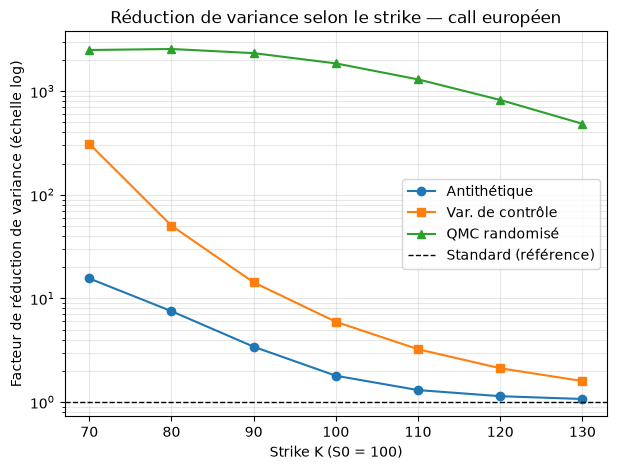

In [9]:
strikes = [70, 80, 90, 100, 110, 120, 130]
vr = {name: [] for name in ["Antithétique", "Var. de contrôle", "QMC randomisé"]}

for K in strikes:
    p = dict(params, K=float(K))
    res = run_all_methods(call_payoff, p, N)
    se_ref = res["Standard"][1]
    for name in vr:
        vr[name].append(se_ref**2 / res[name][1]**2)

print(f"{'K':>5}" + "".join(f"{name:>18}" for name in vr))
for i, K in enumerate(strikes):
    print(f"{K:>5}" + "".join(f"{vr[name][i]:>18.1f}" for name in vr))

plt.figure(figsize=(7, 5))
for name, marker in zip(vr, ["o", "s", "^"]):
    plt.semilogy(strikes, vr[name], marker + "-", label=name)
plt.axhline(1, color="k", ls="--", lw=1, label="Standard (référence)")
plt.xlabel("Strike K (S0 = 100)")
plt.ylabel("Facteur de réduction de variance (échelle log)")
plt.title("Réduction de variance selon le strike — call européen")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("../figures/reduction_variance_strike.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Convergence : erreur standard en fonction du budget

Les méthodes MC (standard, antithétique, contrôle) gardent la pente $-1/2$ : elles ne changent que la constante $\sigma$. Le QMC, lui, a une pente plus raide, proche de $-1$.

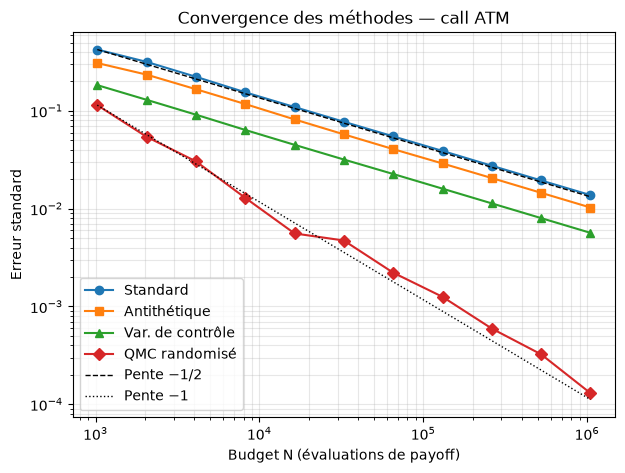

In [10]:
budgets = [2**k for k in range(10, 21)]
se_curves = {name: [] for name in ["Standard", "Antithétique", "Var. de contrôle", "QMC randomisé"]}

for n in budgets:
    se_curves["Standard"].append(mc_standard(call_payoff, **params, n_paths=n, seed=1)[1])
    se_curves["Antithétique"].append(mc_antithetic(call_payoff, **params, n_pairs=n // 2, seed=1)[1])
    se_curves["Var. de contrôle"].append(mc_control_variate(call_payoff, **params, n_paths=n, seed=1)[1])
    se_curves["QMC randomisé"].append(mc_qmc(call_payoff, **params, m=int(np.log2(n // 16)), n_replications=16, seed=1)[1])

b = np.array(budgets, dtype=float)
plt.figure(figsize=(7, 5))
for name, marker in zip(se_curves, ["o", "s", "^", "D"]):
    plt.loglog(b, se_curves[name], marker + "-", label=name)
plt.loglog(b, se_curves["Standard"][0] * np.sqrt(b[0] / b), "k--", lw=1, label=r"Pente $-1/2$")
plt.loglog(b, se_curves["QMC randomisé"][0] * (b[0] / b), "k:", lw=1, label=r"Pente $-1$")
plt.xlabel("Budget N (évaluations de payoff)")
plt.ylabel("Erreur standard")
plt.title("Convergence des méthodes — call ATM")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("../figures/convergence_methodes.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Vérification : biais de la variable de contrôle

On compare $b^*$ estimé sur les mêmes simulations et sur une simulation pilote indépendante. Les deux prix doivent être compatibles avec la formule fermée.

In [11]:
exact = bs_call_price(**params)
for label, n_pilot in [("b* sur les mêmes simulations", 0), ("b* sur un pilote de 10 000", 10_000)]:
    price, se, (lo, hi) = mc_control_variate(call_payoff, **params, n_paths=N, seed=42, n_pilot=n_pilot)
    print(f"{label:<32} prix = {price:.5f}  err. std = {se:.5f}  IC = [{lo:.5f}, {hi:.5f}]  exact dans IC : {lo <= exact <= hi}")

b* sur les mêmes simulations     prix = 9.41806  err. std = 0.01136  IC = [9.39580, 9.44032]  exact dans IC : True
b* sur un pilote de 10 000       prix = 9.41790  err. std = 0.01135  IC = [9.39565, 9.44015]  exact dans IC : True
